In [86]:
import os
from terrain_classification.svm_classification.train_svm import SVMClassification
# from terrain_classification.svm_classification.predict_svm import PredictSVM
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

In [87]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score


In [88]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "terrain_classification"))
files_to_train = {
    # "sand": ["trial1.csv"],
    "sand":     ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv", "trial5.csv", "trial6.csv", "trial7.csv"],#, "trial8.csv", ],
    "wood":   ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv", "trial5.csv", "trial6.csv", "trial7.csv"],#, "trial8.csv", ],
    # "concrete": ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv", "trial5.csv", "trial6.csv", "trial7.csv"],#, "trial8.csv", ],
    "gravel":   ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv", "trial5.csv", "trial6.csv", "trial7.csv"],#, "trial8.csv", ],
    "clay":   ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv", "trial5.csv", "trial6.csv", "trial7.csv"],#, "trial8.csv", ],
    # "sand": ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv"],
    # "wood": ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv"],
    # "concrete": ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv"],
    # "gravel": ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv"],
    # "clay": ["trial1.csv", "trial2.csv", "trial3.csv", "trial4.csv"],
}

data_labels = {}
for key_ in files_to_train.keys():
    for file_ in files_to_train[key_]:
        data_labels[os.path.join(parent_dir, 'data', key_, file_)] = key_

files_to_test = {
    # "sand": ["trial5.csv", "trial6.csv", "trial7.csv", "trial8.csv"],
    # "concrete": ["trial5.csv", "trial6.csv", "trial7.csv", "trial8.csv"],
    # "gravel": ["trial5.csv", "trial6.csv", "trial7.csv", "trial8.csv"],
    "sand":     ["trial8.csv",],
    "wood":   ["trial8.csv",],
    # "concrete": ["trial8.csv",],
    "gravel":   ["trial8.csv",],
    "clay":   ["trial8.csv",],
}

test_data = {}
for key_ in files_to_test.keys():
    for file_ in files_to_test[key_]:
        test_data[os.path.join(parent_dir, 'data', key_, file_)] = key_
        
# data_labels

In [89]:
def adjust_same_length(features_, labels_):
    """
    Adjusts the length of the data arrays to be the same by padding with zeros.
    """
    unique_labels, label_counts = np.unique(labels_, return_counts=True)

    min_count = min(label_counts)
    #extract index of all unique labels
    indices = []
    for label in unique_labels:
        id_ = np.where(labels_ == label)[0]
        if len(id_) >= min_count:
            indices.extend(id_[:min_count])
        else:
            print(f"Warning: Not enough samples for label '{label}'. Found {len(id_)} samples.")
    return features_[indices], labels_[indices]

In [90]:
# Create an instance of the SVMClassification class
svm_classifier = SVMClassification(data_labels)

# Load the data
# cmp = ['x', 'y', 'z']
# cmp = ['x', 'z']
# lgs = ['rl', 'rr']
lgs = ['fl', 'fr', 'rl', 'rr']
cmp = ['x', 'z']
# augment_types = ['add_noise', 'signal_inversion']
# params = [0.1, ""]

comb_legs = False
norm_data = False
comb_comps = True
aug_data = False
augment_types = ['add_noise', 'time_shift',]
params = [0.1, 25,]
svm_classifier.create_feature_matrix_and_label(normalize_data=norm_data,
                            legs=lgs, 
                            components=cmp,
                            combine_components=comb_comps,
                            combine_legs = comb_legs, 
                            augment_data=aug_data,
                            data_padding_size=80,
                            augmetation_types=augment_types,
                            augment_params=params,
                            )
unfiltered_train_labels = svm_classifier.labels.copy()
svm_classifier.feature_matrix, svm_classifier.labels = adjust_same_length(svm_classifier.feature_matrix, svm_classifier.labels)

unique_labels, label_counts = np.unique(svm_classifier.labels, return_counts=True)
for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count} samples")

print(f"ratio {max(label_counts)/min(label_counts)}")
print(f"feature matrix shape: {svm_classifier.feature_matrix.shape}")
print(f"labels shape: {svm_classifier.labels.shape}")
print(f"original data shape: {np.array(svm_classifier.original_data).shape}")

Label clay: 426 samples
Label gravel: 426 samples
Label sand: 426 samples
Label wood: 426 samples
ratio 1.0
feature matrix shape: (1704, 640)
labels shape: (1704,)
original data shape: (1822, 160)


In [91]:
#train with sklearn 
#using python 3.8
report_dir = os.path.join(parent_dir, "svm_classification")
C = [1e3, 1e2, 1e1, 1]
gamma = [ 1e-4, 1e-2, 1e-3,]
# C = [1, 1e1, 1e2]
# gamma = [0.1, 1, 10]
# C = [100]
# gamma = [0.001]
svm_classifier.train_classifier(C=C, gamma=gamma, find_best_parameters=True, 
                                save_model=False, model_file_name="3class_model", 
                                save_report=False, file_path=None)

print("Training completed.")
print("Report: \n")
# print(svm_classifier.report)
svm_classifier.print_classification_report()



[Training] Best Parameters found: {'C': 10.0, 'gamma': 0.001, 'kernel': 'rbf'}
Training completed.
Report: 

              precision    recall  f1-score   support

        clay       0.60      0.62      0.61        90
      gravel       0.57      0.57      0.57        92
        sand       0.52      0.45      0.48        83
        wood       0.52      0.58      0.55        76

    accuracy                           0.55       341
   macro avg       0.55      0.55      0.55       341
weighted avg       0.55      0.55      0.55       341



validation feature matrix shape: (256, 640)
Label clay: 64 samples
Label gravel: 64 samples
Label sand: 64 samples
Label wood: 64 samples
Classification Report:
              precision    recall  f1-score   support

        clay       0.51      0.50      0.50        64
      gravel       0.43      0.42      0.43        64
        sand       0.46      0.34      0.39        64
        wood       0.49      0.62      0.55        64

    accuracy                           0.47       256
   macro avg       0.47      0.47      0.47       256
weighted avg       0.47      0.47      0.47       256

F-beta score (beta=0.5): [0.50393701 0.42519685 0.39285714 0.54794521]


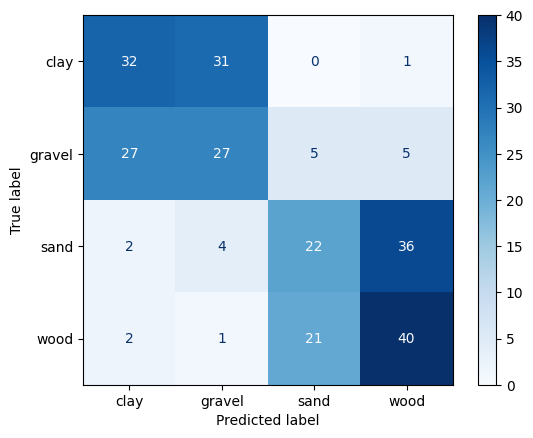

In [96]:

validation_classifier = SVMClassification(test_data)
validation_classifier.create_feature_matrix_and_label(normalize_data=norm_data,
                            legs=lgs, 
                            components=cmp,
                            combine_components=comb_comps, 
                            combine_legs = comb_legs,
                            augment_data=False,
                            data_padding_size=80,
                            augmetation_types=augment_types,
                            augment_params=params,
                            feature_level=None,
                            )
org_validation_labels = validation_classifier.labels.copy()
validation_classifier.feature_matrix, validation_classifier.labels = adjust_same_length(validation_classifier.feature_matrix, validation_classifier.labels)
print(f"validation feature matrix shape: {validation_classifier.feature_matrix.shape}")
unique_labels, label_counts = np.unique(validation_classifier.labels, return_counts=True)
for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count} samples")

# print(f"ratio {max(label_counts)/min(label_counts)}")

# scaler = StandardScaler()
# features_ = scaler.fit_transform(validation_classifier.feature_matrix)
features_ = svm_classifier.scaler.transform(validation_classifier.feature_matrix)
# features_ = validation_classifier.feature_matrix
true_labels_ = validation_classifier.labels
predictions_ = svm_classifier.latest_model.predict(features_)
# Print the classification report
print("Classification Report:")
print(classification_report(true_labels_, predictions_))
cm = ConfusionMatrixDisplay.from_predictions(true_labels_, predictions_, display_labels=svm_classifier.latest_model.classes_, cmap='Blues')

from sklearn.metrics import fbeta_score
f05 = fbeta_score(true_labels_, predictions_, beta=1, average=None)
print(f"F-beta score (beta=0.5): {f05}")

In [ ]:
#evaluate SVM Classifier
comb_leg = [True, False]
norm_data = [True, False]
comp_ = ['z']

if len(comp_) == 2:
    comb_comp = [True, False]
else:
    comb_comp = [True]

lgs = ['fl', 'fr', 'rl', 'rr']
augment_types = ['add_noise', 'time_shift',]
params = [0.1, 25,]
augment = False

for cl in comb_leg:
    for nd in norm_data:
        for cc in comb_comp:
            svm_classifier = SVMClassification(data_labels)
            svm_classifier.create_feature_matrix_and_label(normalize_data=nd,
                            legs=lgs, 
                            components=comp_,
                            combine_components=cc,
                            combine_legs = cl,
                            data_padding_size=70,
                            augment_data=augment, augmetation_types=augment_types, augment_params=params)
            
            svm_classifier.feature_matrix, svm_classifier.labels = adjust_same_length(svm_classifier.feature_matrix, svm_classifier.labels)
            
            C = [1e3, 1e2, 1e1, 1]
            gamma = [ 1e-4, 1e-2, 1e-3,]
           
            svm_classifier.train_classifier(C=C, gamma=gamma, find_best_parameters=True, 
                                            save_model=False, model_file_name="3class_model", 
                                            save_report=False, file_path=None)
            
            validation_classifier = SVMClassification(test_data)
            validation_classifier.create_feature_matrix_and_label(normalize_data=norm_data,
                                        legs=lgs, 
                                        components=comp_,
                                        combine_components=cc,
                                        combine_legs = cl,
                                        data_padding_size=70
                                        )
            validation_classifier.feature_matrix, validation_classifier.labels = adjust_same_length(validation_classifier.feature_matrix, validation_classifier.labels)
            features_ = svm_classifier.scaler.transform(validation_classifier.feature_matrix)            
            true_labels_ = validation_classifier.labels
            predictions_ = svm_classifier.latest_model.predict(features_)
            score_ = accuracy_score(true_labels_, predictions_)
            print(f"combine_leg: {cl} norm_data: {nd} combine_comp: {cc} train_score: {svm_classifier.classification_report['report']['accuracy']:.2f}\
            val_score: {score_:.2f} feature_shape: {svm_classifier.feature_matrix.shape}")
            

In [ ]:
#evaluating random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

comb_leg = [True, False]
norm_data = [True, False]
comb_comp = [True, False]
augment = True
comp_ = ['x', 'z']
lgs = ['fl', 'fr', 'rl', 'rr']
augment_types = ['add_noise', 'time_shift',]
params = [0.1, 25,]

for cl in comb_leg:
    for nd in norm_data:
        for cc in comb_comp:
            svm_classifier = SVMClassification(data_labels)
            scaler = StandardScaler()
            svm_classifier.create_feature_matrix_and_label(normalize_data=nd,
                            legs=lgs, 
                            components=comp_,
                            combine_components=cc,
                            combine_legs = cl,
                            data_padding_size=70,
                            augment_data=augment, augmetation_types=augment_types, augment_params=params)
            
            svm_classifier.feature_matrix, svm_classifier.labels = adjust_same_length(svm_classifier.feature_matrix, svm_classifier.labels)
            svm_classifier.feature_matrix = scaler.fit_transform(svm_classifier.feature_matrix)
            
            param_grid = {
                'n_estimators': [100],
                'max_depth': [10, 20],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2],
                'max_features': ['sqrt']
            }

            rf = RandomForestClassifier(random_state=42)
            grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10, scoring='f1_weighted', verbose=0, n_jobs=-1)
            grid_search.fit(svm_classifier.feature_matrix, svm_classifier.labels)
            print("Best Parameters:", grid_search.best_params_)

            
            validation_classifier = SVMClassification(test_data)
            validation_classifier.create_feature_matrix_and_label(normalize_data=norm_data,
                                        legs=lgs, 
                                        components=comp_,
                                        combine_components=cc,
                                        combine_legs = cl,
                                        data_padding_size=70
                                        )
            validation_classifier.feature_matrix, validation_classifier.labels = adjust_same_length(validation_classifier.feature_matrix, validation_classifier.labels)
            features_ = scaler.transform(validation_classifier.feature_matrix)            
            true_labels_ = validation_classifier.labels

            predictions_ = grid_search.predict(validation_classifier.feature_matrix)
            
            score_ = accuracy_score(true_labels_, predictions_)
            print(f"combine_leg: {cl} norm_data: {nd} combine_comp: {cc} val_score: {score_:.2f} feature_shape: {svm_classifier.feature_matrix.shape}")

In [17]:
# from terrain_classification.svm_classification.predict_svm import SVMPredictor
# from terrain_classification.svm_classification.train_svm import SVMClassification
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import os
# from joblib import load
# # Create an instance of the PredictSVM class
# parent_dir = os.path.abspath(os.path.join(os.getcwd(), "terrain_classification"))
# file_name = "3class_model"
# # file_name = "gravel_concrete_model"
# model_file = os.path.join(parent_dir, "svm_classification/models", f"{file_name}.joblib")
# scaler_path = os.path.join(parent_dir, "svm_classification/models", f"{file_name}-scaler.pkl")
# # scaler = load(scaler_path)
# predictor = SVMPredictor(model_path=model_file)
# two_class_model = load(os.path.join(parent_dir, "svm_classification/models", "2class_model.joblib"))

In [18]:
# #plot samples from each class
# import matplotlib.pyplot as plt

# step_dict = np.array(test_classifier.original_data)
# print(step_dict.shape)
# # print(step_dict.keys())
# plt.figure(figsize=(10, 6))
# for i, label in enumerate(np.unique(test_classifier.labels)):
#     # if label == 'sand':
#     #     continue
#     indices = np.where(test_classifier.labels == label)[0]
#     print(f"Label {label}: {len(indices)} samples")
#     if len(indices) > 0:
#         # Select a random sample from the indices
#         index = np.random.choice(indices)
#         print(f"index: {index}")
#         # Plot the sample
#         # plt.plot(step_dict[index][:, 0], step_dict[index][:, 1], label=label)
#         plt.plot(step_dict[index], label=label)
# plt.title("Samples from each class")
# plt.xlabel("X-axis")
# plt.ylabel("Y-axis")
# plt.legend()
# plt.show()

In [ ]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
# Best Parameters with combined legs: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
rf = RandomForestClassifier(n_estimators=20, max_depth=None, max_features='log2', 
                            min_samples_split=5, random_state=42)
rf.fit(svm_classifier.feature_matrix, svm_classifier.labels)
predictions_rf = rf.predict(validation_classifier.feature_matrix)

# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [10, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# rf = RandomForestClassifier(random_state=42)
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10, scoring='f1_weighted', verbose=2, n_jobs=-1)
# grid_search.fit(svm_classifier.feature_matrix, svm_classifier.labels)
# print("Best Parameters:", grid_search.best_params_)
# predictions_rf = grid_search.predict(validation_classifier.feature_matrix)

print("Random Forest Classification Report:")
print(classification_report(validation_classifier.labels, predictions_rf))
# cm_rf = ConfusionMatrixDisplay.from_predictions(validation_classifier.labels, predictions_rf, display_labels=svm_classifier.latest_model.classes_, cmap='Blues')

In [76]:
#Data preprocessing for MLP
from terrain_classification.wavelet_analysis import WaveletAnalysis
from terrain_classification.data_augmentation import DataAugmentation

wa = WaveletAnalysis()
da = DataAugmentation()

org_data = np.array(svm_classifier.original_data)
# org_labels = np.array(unfiltered_labels)
print(f"org shape: {org_data.shape}")
org_labels = unfiltered_train_labels
# org_labels = org_labels.reshape(-1, 1)

wave_results = np.array(wa.perform_analysis(org_data))
# print(f'wave shape: {wave_results.shape}')
fft_signals = []
for signal in org_data:
    fft_signal = svm_classifier.data_augmentation.low_pass_filter(signal)
    fft_signals.append(fft_signal)

noise_signals = []
for signal in org_data:
    noise_signal = svm_classifier.data_augmentation.add_noise(signal, 0.1)
    noise_signals.append(noise_signal)

# augmented_ = feature_augmentation(['wavelet'], org_data)
# print(f"lenght: {len(fft_signals[0])}")
final_feature_matrix = []
final_labels = []

# aug_types = ['fft', 'wavelets']
# for data, label in zip (org_data, org_labels):

# for data_, fft_sig, wav_res, label in zip(org_data, fft_signals, wave_results, org_labels):
    # final_feature_matrix.append(np.hstack((data_.flatten(), fft_sig.flatten())))
for feature, fft_sig, wav_res, noi,  label in zip(org_data, fft_signals, wave_results, noise_signals, org_labels):
    final_feature_matrix.append(np.hstack((feature.flatten(), noi.flatten(), fft_sig.flatten(), wav_res.flatten())))
    # final_feature_matrix.append(np.hstack((feature.flatten(), fft_sig.flatten())))
    # for aug_typ in aug_types:
    #     augmented_ = feature_augmentation(aug_typ, data)
    final_labels.append(label)

final_feature_matrix = np.array(final_feature_matrix)
final_labels = np.array(final_labels)

# final_feature_matrix, final_labels = adjust_same_length(final_feature_matrix, final_labels)
print(f'feature size: {final_feature_matrix.shape}')
print(f'label size: {final_labels.shape}')

org shape: (511, 640)
feature size: (511, 5760)
label size: (511,)


In [1]:
# from scipy import fft
# from terrain_classification.wavelet_analysis import WaveletAnalysis
# from terrain_classification.data_augmentation import DataAugmentation

# wa = WaveletAnalysis()
# da = DataAugmentation()

# def feature_augmentation (names, signals):
#     augmented_sig = []
#     for name in names:
#         if name == 'fft':
#             # for sig in signals:
#             fft_sig = da.low_pass_filter(signals)
#             augmented_sig.append(fft_sig.flatten())

#         if name == 'wavelet':
#             wave_result = wa.perform_analysis(signals)

#             for res in wave_result:
#                 augmented_sig.append(res.flatten())

#     return augmented_sig

# org_data = np.array(svm_classifier.original_data)
# # org_labels = np.array(unfiltered_labels)
# print(f"org shape: {org_data.shape}")
# org_labels = unfiltered_train_labels
# # org_labels = org_labels.reshape(-1, 1)

# wave_results = np.array(wa.perform_analysis(org_data))
# # print(f'wave shape: {wave_results.shape}')
# fft_signals = []
# for signal in org_data:
#     fft_signal = svm_classifier.data_augmentation.low_pass_filter(signal)
#     fft_signals.append(fft_signal)

# # augmented_ = feature_augmentation(['wavelet'], org_data)
# print(f"lenght: {len(fft_signals[0])}")
# final_feature_matrix = []
# final_labels = []

# aug_types = ['wavelets']
# for data, label in zip (org_data, org_labels):
#     aug_ = feature_augmentation(aug_types, data)
#     print(f'aug shape: {np.array(aug_).shape}')

# # for data_, fft_sig, wav_res, label in zip(org_data, fft_signals, wave_results, org_labels):
#     # final_feature_matrix.append(np.hstack((data_.flatten(), fft_sig.flatten())))
# # for feature, fft_sig, wav_res, label in zip(org_data, fft_signals, wave_results, org_labels):
# #     final_feature_matrix.append(np.hstack((feature.flatten(), fft_sig.flatten(), wav_res.flatten())))
# #     # for aug_typ in aug_types:
# #     #     augmented_ = feature_augmentation(aug_typ, data)
# #     final_labels.append(label)

# final_feature_matrix = np.array(final_feature_matrix)
# final_labels = np.array(final_labels)
# print(f'feature size: {final_feature_matrix.shape}')
# print(f'label size: {final_labels.shape}')

X shape: (511, 5760)
['clay' 'concrete' 'gravel' 'sand' 'wood']
Label 0: 95 samples
Label 1: 97 samples
Label 2: 110 samples
Label 3: 105 samples
Label 4: 104 samples
Epoch 0, Loss: 1.6157
Epoch 500, Loss: 0.0160
Epoch 1000, Loss: 0.0137
Epoch 1500, Loss: 0.0155
Epoch 2000, Loss: 0.0095
Epoch 2500, Loss: 0.0135
              precision    recall  f1-score   support

           0       0.53      0.53      0.53        19
           1       0.71      0.60      0.65        20
           2       0.57      0.55      0.56        22
           3       0.54      0.71      0.61        21
           4       0.50      0.43      0.46        21

    accuracy                           0.56       103
   macro avg       0.57      0.56      0.56       103
weighted avg       0.57      0.56      0.56       103



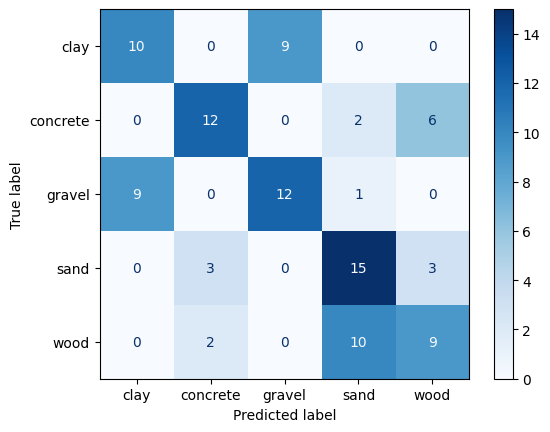

In [79]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

def convert_labels(labels):
    # Convert string labels to integers
    label_map = {}
    label_map['sand'] = 0
    label_map['gravel'] = 1
    label_map['wood'] = 2
    label_map['clay'] = 3
    label_map['concrete'] = 4
    return np.array([label_map[label] for label in labels], dtype=int)

# Sample input data: assume X is (n_samples, n_features)
# X = ...  # wavelet-transformed features
# y = ...  # labels: 0=concrete, 1=gravel, 2=sand
# X = svm_classifier.feature_matrix
# X = org_data
X = final_feature_matrix
print(f"X shape: {X.shape}")
# y = convert_labels(svm_classifier.labels)
y = convert_labels(final_labels)
op_class, label_counts = np.unique(final_labels, return_counts=True)
# y = convert_labels(org_labels)
# op_class, label_counts = np.unique(org_labels, return_counts=True)
print(op_class)
ul, lc = np.unique(y, return_counts=True)
for label, count in zip(ul, lc):
    print(f"Label {label}: {count} samples")


# Preprocess
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_validation_tensor = torch.tensor(validation_classifier.original_data, dtype=torch.float32)
y_validation_tensor = torch.tensor(convert_labels(org_validation_labels), dtype=torch.long)


# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        """
        Args:
            input_size (int): Number of input features.
            hidden_layers (list): List of integers specifying the number of neurons in each hidden layer.
            output_size (int): Number of output classes.
        """
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size

        # Add hidden layers dynamically
        for i, hidden_size in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())  # You can replace ReLU with other activation functions
            layers.append(nn.Dropout(0.1))  # Optional dropout
            prev_size = hidden_size

        # Add the output layer
        layers.append(nn.Linear(prev_size, output_size))

        # Create the sequential model
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss

# model = MLP(input_size=X.shape[1])
# Example usage
input_size = X.shape[1]
hidden_layers = [256, 128, 64, 16]  # Three hidden layers
output_size = len(op_class)

model = MLP(input_size, hidden_layers, output_size)
# Training setup
criterion = nn.CrossEntropyLoss()
# criterion = FocalLoss(alpha=1, gamma=2.0)
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

epochs = 1000*3

# Training loop
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor).argmax(dim=1)
    print(classification_report(y_test_tensor, preds))
    ConfusionMatrixDisplay.from_predictions(y_test_tensor, preds, display_labels=op_class, cmap='Blues')
    # preds = model(X_validation_tensor).argmax(dim=1)
    # print(classification_report(y_validation_tensor, preds))


Voting Classifier Classification Report:
              precision    recall  f1-score   support

    concrete       0.30      0.55      0.39        74
      gravel       0.32      0.36      0.34        74
        sand       0.00      0.00      0.00        74

    accuracy                           0.31       222
   macro avg       0.21      0.31      0.24       222
weighted avg       0.21      0.31      0.24       222



/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (2).

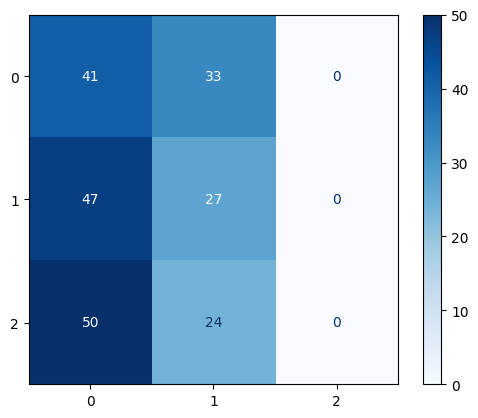

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[('rf', rf), ('svc', svm_classifier.latest_model)], voting='hard')
voting_clf.fit(svm_classifier.feature_matrix, svm_classifier.labels)
predictions_voting = voting_clf.predict(test_classifier.feature_matrix)
print("Voting Classifier Classification Report:")
print(classification_report(test_classifier.labels, predictions_voting))
ConfusionMatrixDisplay.from_predictions(test_classifier.labels, predictions_voting, display_labels=voting_clf.classes_, cmap='Blues')

[Voting] ..................... (1 of 2) Processing svc3, total=  18.7s
[Voting] ..................... (2 of 2) Processing svc2, total=  18.7s
Ensemble Classifier Classification Report:
              precision    recall  f1-score   support

    concrete       0.28      0.24      0.26        74
      gravel       0.37      0.42      0.39        74
        sand       0.61      0.61      0.61        74

    accuracy                           0.42       222
   macro avg       0.42      0.42      0.42       222
weighted avg       0.42      0.42      0.42       222



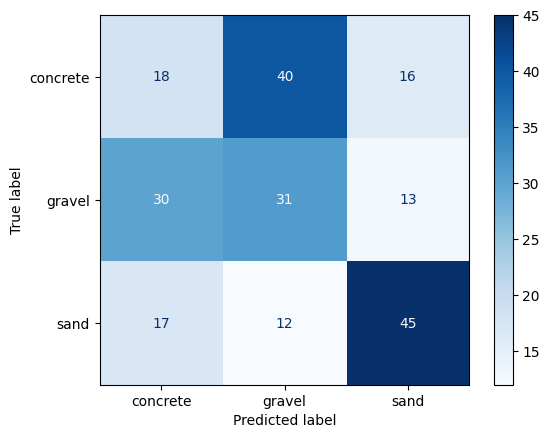

In [ ]:
#two and three class ensemble
from sklearn.ensemble import VotingClassifier

two_three_ensemble = VotingClassifier(estimators=[
                    ('svc3', predictor.model), 
                    ('svc2', two_class_model)], voting='hard', 
                    weights=[10, 1], verbose=2)
two_three_ensemble.fit(svm_classifier.feature_matrix, svm_classifier.labels)
predictions_ensemble = two_three_ensemble.predict(test_classifier.feature_matrix)
print("Ensemble Classifier Classification Report:")
print(classification_report(test_classifier.labels, predictions_ensemble))
ConfusionMatrixDisplay.from_predictions(test_classifier.labels, predictions_ensemble, 
                                        cmap='Blues')

In [ ]:
# Custom ensemble prediction
def custom_ensemble_predict(X):
    # Get probabilities from both models
    prob_three_class = predictor.model.predict_proba(X)
    # print("prob_three_class", prob_three_class)
    prob_two_class = two_class_model.predict_proba(X)
    # print("prob_two_class", prob_two_class)

    # Combine predictions (example: prioritize three-class SVC)
    final_predictions = []
    for i, prob in enumerate(prob_two_class):
        if max(prob) > 0.7:  # High confidence from three-class SVC
            final_predictions.append(predictor.model.classes_[np.argmax(prob)])
        else:  # Use two-class SVC for refinement
            final_predictions.append(two_class_model.classes_[np.argmax(prob_three_class[i])])
    return final_predictions

custom_predictions = custom_ensemble_predict(features_)

print("Custom Ensemble Classifier Classification Report:")
print(classification_report(true_labels_, custom_predictions))
ConfusionMatrixDisplay.from_predictions(true_labels_, custom_predictions, 
                                         cmap='Blues')

ValueError: X has 560 features, but SVC is expecting 800 features as input.

In [ ]:

# #to train with cuML, we need to convert the labels to integers
# l_ = ['sand', 'gravel', 'concrete']
# min_len = [len(np.where(svm_classifier.labels == l)[0]) for l in l_ if len(np.where(svm_classifier.labels == l)[0]) > 0]

# print(f"min_len {min_len}")
# new_ids = np.empty(0)

# if use_sand:
#     new_ids = np.concatenate((new_ids, np.where(svm_classifier.labels == 'sand')[0]))
# if use_gravel:
#     new_ids = np.concatenate((new_ids, np.where(svm_classifier.labels == 'gravel')[0]))
# if use_concrete:
#     new_ids = np.concatenate((new_ids, np.where(svm_classifier.labels == 'concrete')[0]))

# new_ids = new_ids.astype(int)
# new_labels = svm_classifier.labels[new_ids]
# new_features = svm_classifier.feature_matrix[new_ids]

# print(f"new labels shape {new_labels.shape}")
# print(f"new features shape {new_features.shape}")


In [ ]:
def convert_labels(labels):
    # Convert string labels to integers
    label_map = {}
    label_map['sand'] = 0
    label_map['gravel'] = 1
    label_map['concrete'] = 2
    return np.array([label_map[label] for label in labels], dtype=int)

In [ ]:
#use miniconda python 3.12
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(svm_classifier.feature_matrix, svm_classifier.labels, test_size=0.2, random_state=42)
# new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_features, new_labels, test_size=0.2, random_state=42)
# print(f"X type {new_X_train.dtype}")
# print(f"y type {new_y_train.dtype}")
orig_label_train = new_y_train
orig_label_test = new_y_test
new_y_train = convert_labels(new_y_train)
new_y_test = convert_labels(new_y_test)

scaler = StandardScaler()
new_X_train = scaler.fit_transform(new_X_train)
new_X_test = scaler.transform(new_X_test)


In [ ]:

from cuml.svm import SVC as cmSVC
from cuml.metrics import accuracy_score

# print("Creating SVC model")
# c = [0.1, 1, 10, 100]
c = [1000, 10, 100]
g = [0.001, 0.01, 0.1, 1]
# g = ['scale', 'auto']
# g = [0.01, 1]
kernel = ['rbf']
# kernel = ['rbf', 'poly', 'sigmoid']
c
# for c_, g_ in zip(c, g):
for k_ in kernel:
    for c_ in c:
        for g_ in g:
        # print(f"Trying c: {c_} g: {g_}")
        # print(f"accuracy {accuracy_score(new_y_pred, new_y_test)}")
            new_svc = cmSVC(kernel=k_, C=c_, gamma=g_, cache_size=2000)
            new_svc.fit(new_X_train, new_y_train)
            new_y_pred = new_svc.predict(new_X_test)
            print(f"Trying c: {c_} g: {g_} kernel: {k_} -> Accuracy score: {accuracy_score(new_y_pred, new_y_test):.4f}") 
            # print(classification_report(new_y_test, new_y_pred))
            # print("=========================")
        print("----------------------")
    print("----------------------")

print("All Done")

In [ ]:
from joblib import dump
from cuml.svm import SVC as cmSVC

# from sklearn.externals import joblib

new_svc = cmSVC(kernel='rbf', C=100, gamma=0.01, cache_size=2000)
new_svc.fit(new_X_train, new_y_train)
print("Training done")
# sk_model = new_svc.to_sklearn()
# dump(sk_model, os.path.join(parent_dir, 'svm_classification/cpu_test_model.joblib'))

In [ ]:
from joblib import load
# import cuml
from sklearn.metrics import classification_report
loaded_model = load(os.path.join(parent_dir, 'svm_classification/models/trained_test_model.joblib'))
print(f"loaded model {loaded_model}")

predictions_ = loaded_model.predict(new_X_train)
print(classification_report(orig_label_train, predictions_))
# print(f"Accuracy: {accuracy_score(new_y_test, predictions_):.4f}")